# **Chaves primárias e chaves estrangeiras**

**Identificando se as colunas que terminam com id podem ser chaves primárias das tabelas**

```sql

SELECT
    'market_fact' AS tabela,
    'Cust_id' as coluna_analisada,
    COUNT(*) AS total_linhas,
    COUNT(m."Cust_id") AS total_ids_preenchidos,
    COUNT(DISTINCT m."Cust_id") AS total_ids_unicos
FROM db_global_sales.market_fact AS m

UNION ALL

SELECT
    'orders_dimen' AS tabela,
    'Order_ID' as coluna_analisada,
    COUNT(*) AS total_linhas,
    COUNT(o."Order_ID") AS total_ids_preenchidos,
    COUNT(DISTINCT o."Order_ID") AS total_ids_unicos
FROM db_global_sales.orders_dimen AS o

UNION ALL

SELECT
    'orders_dimen' AS tabela,
    'Ord_id' as coluna_analisada,
    COUNT(*) AS total_linhas,
    COUNT(o."Ord_id") AS total_ids_preenchidos,
    COUNT(DISTINCT o."Ord_id") AS total_ids_unicos
FROM db_global_sales.orders_dimen AS o

UNION ALL

SELECT
    'prod_dimen' AS tabela,
    'Prod_id' as coluna_analisada,
    COUNT(*) AS total_linhas,
    COUNT(p."Prod_id") AS total_ids_preenchidos,
    COUNT(DISTINCT p."Prod_id") AS total_ids_unicos
FROM db_global_sales.prod_dimen AS p

UNION ALL

SELECT
    'shipping_dimen' AS tabela,
    'Ship_id' as coluna_analisada,
    COUNT(*) AS total_linhas,
    COUNT(s."Ship_id") AS total_ids_preenchidos,
    COUNT(DISTINCT s."Ship_id") AS total_ids_unicos
FROM db_global_sales.shipping_dimen AS s;


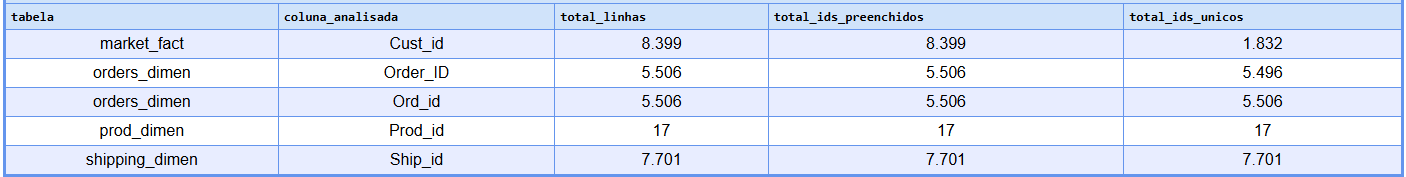

**Agora queremos verificar se os valores das chaves estrangeiras na tabela fato possuem correspondência nas chaves primárias das dimensões.**

```sql

SELECT
    'market_fact' AS tabela_fato,
    'Ord_id' AS coluna_fk,
    'order_dimen' AS tabela_dimensao,
    'Ord_id' AS coluna_pk,
    COUNT(*) AS total_linhas,
    COUNT(m."Ord_id") AS total_fks_preenchidas,
    COUNT(o."Ord_id") AS total_fks_com_correspondencia,
    COUNT(m."Ord_id") - COUNT(o."Ord_id") AS total_fks_sem_correspondencia
FROM db_global_sales.market_fact AS m
LEFT JOIN db_global_sales.orders_dimen AS o
    ON m."Ord_id" = o."Ord_id"

UNION ALL

SELECT
    'market_fact' AS tabela_fato,
    'Prod_id' AS coluna_fk,
    'prod_dimen' AS tabela_dimensao,
    'Prod_id' AS coluna_pk,
    COUNT(*) AS total_linhas,
    COUNT(m."Prod_id") AS total_fks_preenchidas,
    COUNT(p."Prod_id") AS total_fks_com_correspondencia,
    COUNT(m."Prod_id") - COUNT(p."Prod_id") AS total_fks_sem_correspondencia
FROM db_global_sales.market_fact AS m
LEFT JOIN db_global_sales.prod_dimen AS p
    ON m."Prod_id" = p."Prod_id"

    UNION all

SELECT
    'market_fact' AS tabela_fato,
    'Ship_id' AS coluna_fk,
    'shipping_dimen' AS tabela_dimensao,
    'Ship_id' AS coluna_pk,
    COUNT(*) AS total_linhas,
    COUNT(m."Ship_id") AS total_fks_preenchidas,
    COUNT(s."Ship_id") AS total_fks_com_correspondencia,
    COUNT(m."Ship_id") - COUNT(s."Ship_id") AS total_fks_sem_correspondencia
FROM db_global_sales.market_fact AS m
LEFT JOIN db_global_sales.shipping_dimen AS s
    ON m."Ship_id" = s."Ship_id";

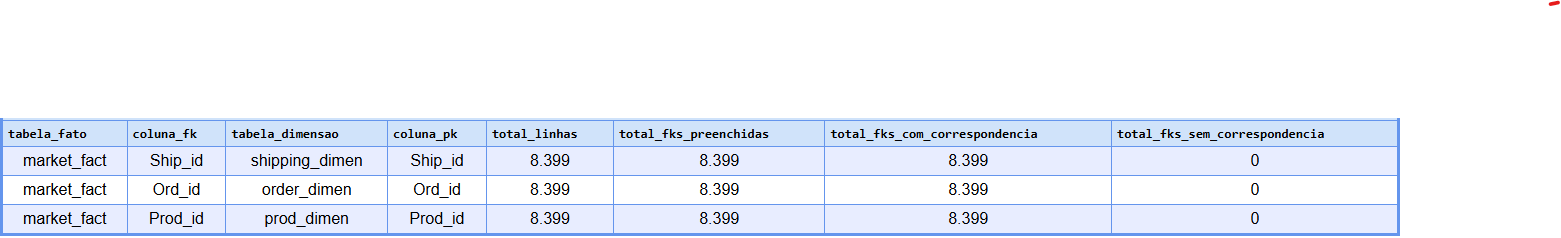

# **Mapeamento das colunas de market_fact:**

**Verificando a granularidade da tabela Sales. É uma linha por combinação de produto, pedido e entrega?**

```sql

SELECT

    ("Ord_id" || '-' || "Prod_id" || '-' || "Ship_id") AS chave,    

    COUNT("Ord_id" || '-' || "Prod_id" || '-' || "Ship_id") AS combinacoes

FROM db_global_sales.market_fact AS s

GROUP BY

    chave

ORDER BY combinacoes DESC;

**Não**

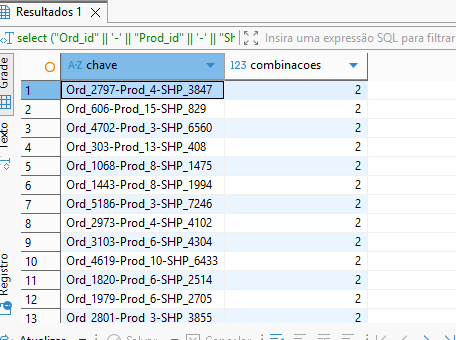

**Verificando a granularidade da tabela Sales. É uma linha por combinação de produto, pedido e entrega e cust_id?**

```sql
SELECT
    ("Ord_id" || '-' || "Prod_id" || '-' || "Ship_id" || '-' || "Cust_id") AS chave,
    COUNT("Ord_id" || '-' || "Prod_id" || '-' || "Ship_id" || '-' || "Cust_id") AS combinacoes

FROM db_global_sales.market_fact AS s

GROUP BY
    chave

ORDER BY combinacoes DESC;

**Não**


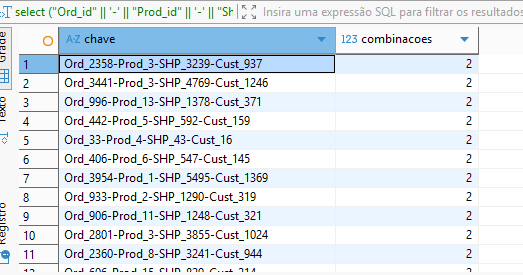

**Verificando se existem duplicatas exatas**

```sql
SELECT
    "Ord_id",
    "Prod_id",
    "Ship_id",
    "Cust_id",
    "Sales",
    "Discount",
    "Order_Quantity",
    "Profit",
    "Shipping_Cost",
    "Product_Base_Margin",
    COUNT(*) AS qtd_registros
FROM db_global_sales.market_fact
GROUP BY
    "Ord_id",
    "Prod_id",
    "Ship_id",
    "Cust_id",
    "Sales",
    "Discount",
    "Order_Quantity",
    "Profit",
    "Shipping_Cost",
    "Product_Base_Margin"
HAVING COUNT(*) > 1
ORDER BY qtd_registros DESC;

**Nenhuma linha retornada.**

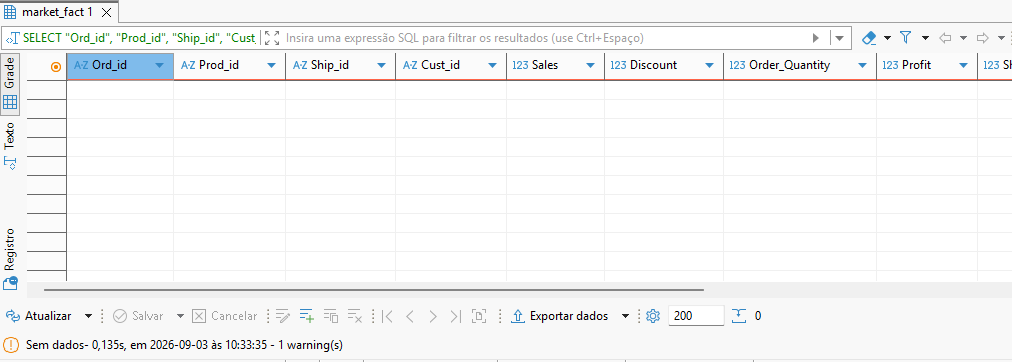


**Check final**

```sql

SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT ("Ord_id", "Prod_id")) AS ord_prod,
    COUNT(DISTINCT ("Ord_id", "Prod_id", "Ship_id")) AS ord_prod_ship,
    COUNT(DISTINCT ("Ord_id", "Prod_id", "Ship_id", "Cust_id")) AS ord_prod_ship_cust
FROM db_global_sales.market_fact;

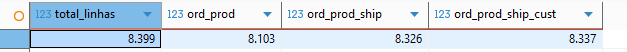

**Mapeamento dos dados da tabela**

```sql

WITH

sales AS (

    WITH estatisticas AS (

        SELECT
            'Sales' AS nome_coluna,
            pg_typeof(m."Sales") AS tipo_dado,
            COUNT(DISTINCT m."Sales") AS unicos,
            COUNT(*) - COUNT(m."Sales") AS nulos,
            MIN(m."Sales")::double precision AS min_,
            MAX(m."Sales")::double precision AS max_,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY m."Sales") AS q_1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY m."Sales") AS q_3
        FROM db_global_sales.market_fact AS m
        GROUP BY tipo_dado

    )

    SELECT
        *,
        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,
        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Sales" <
                  estatisticas.q_1 - 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_inferiores,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Sales" >
                  estatisticas.q_3 + 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_superiores

    FROM estatisticas
),


discount AS (

    WITH estatisticas AS (

        SELECT
            'Discount' AS nome_coluna,
            pg_typeof(m."Discount") AS tipo_dado,
            COUNT(DISTINCT m."Discount") AS unicos,
            COUNT(*) - COUNT(m."Discount") AS nulos,
            MIN(m."Discount")::double precision AS min_,
            MAX(m."Discount")::double precision AS max_,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY m."Discount") AS q_1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY m."Discount") AS q_3
        FROM db_global_sales.market_fact AS m
        GROUP BY tipo_dado

    )

    SELECT
        *,
        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,
        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Discount" <
                  estatisticas.q_1 - 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_inferiores,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Discount" >
                  estatisticas.q_3 + 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_superiores

    FROM estatisticas
),


order_quantity AS (

    WITH estatisticas AS (

        SELECT
            'Order_Quantity' AS nome_coluna,
            pg_typeof(m."Order_Quantity") AS tipo_dado,
            COUNT(DISTINCT m."Order_Quantity") AS unicos,
            COUNT(*) - COUNT(m."Order_Quantity") AS nulos,
            MIN(m."Order_Quantity")::double precision AS min_,
            MAX(m."Order_Quantity")::double precision AS max_,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY m."Order_Quantity") AS q_1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY m."Order_Quantity") AS q_3
        FROM db_global_sales.market_fact AS m
        GROUP BY tipo_dado

    )

    SELECT
        *,
        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,
        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Order_Quantity" <
                  estatisticas.q_1 - 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_inferiores,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Order_Quantity" >
                  estatisticas.q_3 + 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_superiores

    FROM estatisticas
),



profit AS (

    WITH estatisticas AS (

        SELECT
            'Profit' AS nome_coluna,
            pg_typeof(m."Profit") AS tipo_dado,
            COUNT(DISTINCT m."Profit") AS unicos,
            COUNT(*) - COUNT(m."Profit") AS nulos,
            MIN(m."Profit")::double precision AS min_,
            MAX(m."Profit")::double precision AS max_,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY m."Profit") AS q_1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY m."Profit") AS q_3
        FROM db_global_sales.market_fact AS m
        GROUP BY tipo_dado

    )

    SELECT
        *,
        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,
        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Profit" <
                  estatisticas.q_1 - 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_inferiores,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Profit" >
                  estatisticas.q_3 + 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_superiores

    FROM estatisticas
),


shipping_cost AS (

    WITH estatisticas AS (

        SELECT
            'Shipping_Cost' AS nome_coluna,
            pg_typeof(m."Shipping_Cost") AS tipo_dado,
            COUNT(DISTINCT m."Shipping_Cost") AS unicos,
            COUNT(*) - COUNT(m."Shipping_Cost") AS nulos,
            MIN(m."Shipping_Cost")::double precision AS min_,
            MAX(m."Shipping_Cost")::double precision AS max_,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY m."Shipping_Cost") AS q_1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY m."Shipping_Cost") AS q_3
        FROM db_global_sales.market_fact AS m
        GROUP BY tipo_dado

    )

    SELECT
        *,
        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,
        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Shipping_Cost" <
                  estatisticas.q_1 - 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_inferiores,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Shipping_Cost" >
                  estatisticas.q_3 + 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_superiores

    FROM estatisticas
),


product_base_margin AS (

    WITH estatisticas AS (

        SELECT
            'Product_Base_Margin' AS nome_coluna,
            pg_typeof(m."Product_Base_Margin") AS tipo_dado,
            COUNT(DISTINCT m."Product_Base_Margin") AS unicos,
            COUNT(*) - COUNT(m."Product_Base_Margin") AS nulos,
            MIN(m."Product_Base_Margin")::double precision AS min_,
            MAX(m."Product_Base_Margin")::double precision AS max_,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY m."Product_Base_Margin") AS q_1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY m."Product_Base_Margin") AS q_3
        FROM db_global_sales.market_fact AS m
        GROUP BY tipo_dado

    )

    SELECT
        *,
        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,
        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Product_Base_Margin" <
                  estatisticas.q_1 - 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_inferiores,

        (
            SELECT COUNT(*)
            FROM db_global_sales.market_fact AS m
            WHERE m."Product_Base_Margin" >
                  estatisticas.q_3 + 1.5 * (estatisticas.q_3 - estatisticas.q_1)
        ) AS outliers_superiores

    FROM estatisticas
),


ord_id AS (

    SELECT
        'Ord_id' AS nome_coluna,
        pg_typeof(m."Ord_id") AS tipo_dado,
        COUNT(DISTINCT m."Ord_id") AS unicos,
        COUNT(*) - COUNT(m."Ord_id") AS nulos,
        NULL::double precision AS min_,
        NULL::double precision AS max_,
        NULL::double precision AS q_1,
        NULL::double precision AS q_3,
        NULL::double precision AS limite_inferior,
        NULL::double precision AS limite_superior,
        NULL::bigint AS outliers_inferiores,
        NULL::bigint AS outliers_superiores
    FROM db_global_sales.market_fact AS m
    GROUP BY pg_typeof(m."Ord_id")

),

prod_id AS (

    SELECT
        'Prod_id',
        pg_typeof(m."Prod_id"),
        COUNT(DISTINCT m."Prod_id"),
        COUNT(*) - COUNT(m."Prod_id"),
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::bigint,
        NULL::bigint
    FROM db_global_sales.market_fact AS m
    GROUP BY pg_typeof(m."Prod_id")

),

ship_id AS (

    SELECT
        'Ship_id',
        pg_typeof(m."Ship_id"),
        COUNT(DISTINCT m."Ship_id"),
        COUNT(*) - COUNT(m."Ship_id"),
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::bigint,
        NULL::bigint
    FROM db_global_sales.market_fact AS m
    GROUP BY pg_typeof(m."Ship_id")

),

cust_id AS (

    SELECT
        'Cust_id',
        pg_typeof(m."Cust_id"),
        COUNT(DISTINCT m."Cust_id"),
        COUNT(*) - COUNT(m."Cust_id"),
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::double precision,
        NULL::bigint,
        NULL::bigint
    FROM db_global_sales.market_fact AS m
    GROUP BY pg_typeof(m."Cust_id")

)


SELECT * FROM sales

UNION ALL

SELECT * FROM discount

UNION ALL

SELECT * FROM order_quantity

UNION ALL

SELECT * FROM profit

UNION ALL

SELECT * FROM shipping_cost

UNION ALL

SELECT * FROM product_base_margin

UNION ALL

SELECT * FROM ord_id

UNION ALL

SELECT * FROM prod_id

UNION ALL

SELECT * FROM ship_id

UNION ALL

SELECT * FROM cust_id;

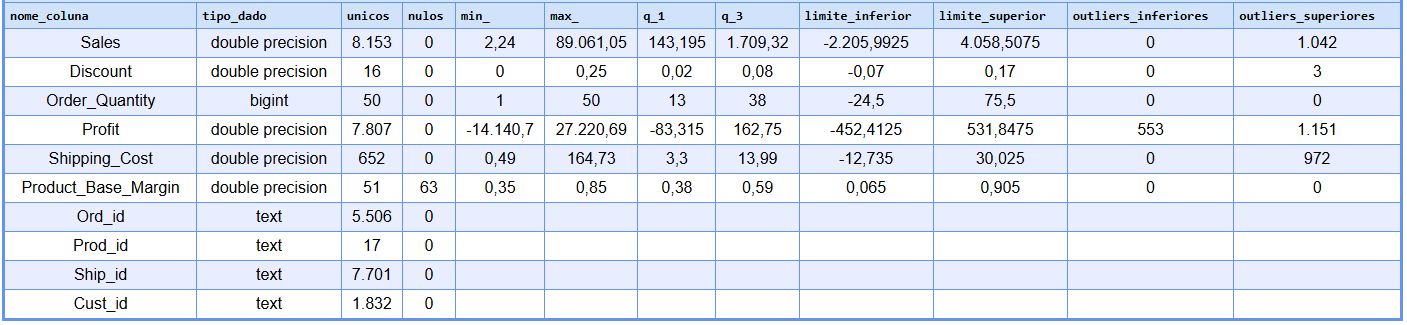

**Criando colunas de venda, lucro e custo por unidade e recalculando o mapeamento inicial, a fim de verificar se há outliers com esses indicadores**

```sql

WITH novas_colunas AS (

    SELECT

        m."Sales" / NULLIF(m."Order_Quantity", 0) AS venda_por_unidade,

        m."Profit" / NULLIF(m."Order_Quantity", 0) AS lucro_por_unidade,

        m."Shipping_Cost" / NULLIF(m."Order_Quantity", 0) AS custo_por_unidade

    FROM db_global_sales.market_fact AS m

),

venda_por_unidade AS (

    WITH estatisticas AS (

        SELECT

            'venda_por_unidade' AS nome_coluna,

            pg_typeof("venda_por_unidade") AS tipo_dado,

            COUNT(DISTINCT "venda_por_unidade") AS unicos,

            COUNT(*) - COUNT("venda_por_unidade") AS nulos,

            MIN("venda_por_unidade")::double precision AS min_,

            MAX("venda_por_unidade")::double precision AS max_,

            PERCENTILE_CONT(0.05)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS percentil_05,

            PERCENTILE_CONT(0.25)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS q_1,

            PERCENTILE_CONT(0.75)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS q_3,

            PERCENTILE_CONT(0.95)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS percentil_95

        FROM novas_colunas

        GROUP BY tipo_dado

    )

    SELECT

        *,

        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,

        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" <

                  estatisticas.q_1

                  - 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_inferiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" >

                  estatisticas.q_3

                  + 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_superiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" <

                  estatisticas.percentil_05

        ) AS abaixo_percentil_05,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" >

                  estatisticas.percentil_95

        ) AS acima_percentil_95

    FROM estatisticas

),

lucro_por_unidade AS (

    WITH estatisticas AS (

        SELECT

            'lucro_por_unidade' AS nome_coluna,

            pg_typeof("lucro_por_unidade") AS tipo_dado,

            COUNT(DISTINCT "lucro_por_unidade") AS unicos,

            COUNT(*) - COUNT("lucro_por_unidade") AS nulos,

            MIN("lucro_por_unidade")::double precision AS min_,

            MAX("lucro_por_unidade")::double precision AS max_,

            PERCENTILE_CONT(0.05)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS percentil_05,

            PERCENTILE_CONT(0.25)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS q_1,

            PERCENTILE_CONT(0.75)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS q_3,

            PERCENTILE_CONT(0.95)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS percentil_95

        FROM novas_colunas

        GROUP BY tipo_dado

    )

    SELECT

        *,

        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,

        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" <

                  estatisticas.q_1

                  - 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_inferiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" >

                  estatisticas.q_3

                  + 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_superiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" <

                  estatisticas.percentil_05

        ) AS abaixo_percentil_05,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" >

                  estatisticas.percentil_95

        ) AS acima_percentil_95

    FROM estatisticas

),

custo_por_unidade AS (

    WITH estatisticas AS (

        SELECT

            'custo_por_unidade' AS nome_coluna,

            pg_typeof("custo_por_unidade") AS tipo_dado,

            COUNT(DISTINCT "custo_por_unidade") AS unicos,

            COUNT(*) - COUNT("custo_por_unidade") AS nulos,

            MIN("custo_por_unidade")::double precision AS min_,

            MAX("custo_por_unidade")::double precision AS max_,

            PERCENTILE_CONT(0.05)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS percentil_05,

            PERCENTILE_CONT(0.25)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS q_1,

            PERCENTILE_CONT(0.75)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS q_3,

            PERCENTILE_CONT(0.95)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS percentil_95

        FROM novas_colunas

        GROUP BY tipo_dado

    )

    SELECT

        *,

        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,

        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" <

                  estatisticas.q_1

                  - 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_inferiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" >

                  estatisticas.q_3

                  + 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_superiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" <

                  estatisticas.percentil_05

        ) AS abaixo_percentil_05,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" >

                  estatisticas.percentil_95

        ) AS acima_percentil_95

    FROM estatisticas

)

SELECT *

FROM venda_por_unidade

UNION ALL

SELECT *

FROM lucro_por_unidade

UNION ALL

SELECT *

FROM custo_por_unidade

ORDER BY nome_coluna;












WITH novas_colunas AS (

    SELECT

        m."Sales" / NULLIF(m."Order_Quantity", 0) AS venda_por_unidade,

        m."Profit" / NULLIF(m."Order_Quantity", 0) AS lucro_por_unidade,

        m."Shipping_Cost" / NULLIF(m."Order_Quantity", 0) AS custo_por_unidade

    FROM db_global_sales.market_fact AS m

),

venda_por_unidade AS (

    WITH estatisticas AS (

        SELECT

            'venda_por_unidade' AS nome_coluna,

            pg_typeof("venda_por_unidade") AS tipo_dado,

            COUNT(DISTINCT "venda_por_unidade") AS unicos,

            COUNT(*) - COUNT("venda_por_unidade") AS nulos,

            MIN("venda_por_unidade")::double precision AS min_,

            MAX("venda_por_unidade")::double precision AS max_,

            PERCENTILE_CONT(0.05)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS percentil_05,

            PERCENTILE_CONT(0.25)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS q_1,

            PERCENTILE_CONT(0.75)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS q_3,

            PERCENTILE_CONT(0.95)
                WITHIN GROUP (ORDER BY "venda_por_unidade") AS percentil_95

        FROM novas_colunas

        GROUP BY tipo_dado

    )

    SELECT

        *,

        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,

        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" <

                  estatisticas.q_1

                  - 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_inferiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" >

                  estatisticas.q_3

                  + 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_superiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" <

                  estatisticas.percentil_05

        ) AS abaixo_percentil_05,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."venda_por_unidade" >

                  estatisticas.percentil_95

        ) AS acima_percentil_95

    FROM estatisticas

),

lucro_por_unidade AS (

    WITH estatisticas AS (

        SELECT

            'lucro_por_unidade' AS nome_coluna,

            pg_typeof("lucro_por_unidade") AS tipo_dado,

            COUNT(DISTINCT "lucro_por_unidade") AS unicos,

            COUNT(*) - COUNT("lucro_por_unidade") AS nulos,

            MIN("lucro_por_unidade")::double precision AS min_,

            MAX("lucro_por_unidade")::double precision AS max_,

            PERCENTILE_CONT(0.05)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS percentil_05,

            PERCENTILE_CONT(0.25)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS q_1,

            PERCENTILE_CONT(0.75)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS q_3,

            PERCENTILE_CONT(0.95)
                WITHIN GROUP (ORDER BY "lucro_por_unidade") AS percentil_95

        FROM novas_colunas

        GROUP BY tipo_dado

    )

    SELECT

        *,

        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,

        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" <

                  estatisticas.q_1

                  - 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_inferiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" >

                  estatisticas.q_3

                  + 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_superiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" <

                  estatisticas.percentil_05

        ) AS abaixo_percentil_05,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."lucro_por_unidade" >

                  estatisticas.percentil_95

        ) AS acima_percentil_95

    FROM estatisticas

),

custo_por_unidade AS (

    WITH estatisticas AS (

        SELECT

            'custo_por_unidade' AS nome_coluna,

            pg_typeof("custo_por_unidade") AS tipo_dado,

            COUNT(DISTINCT "custo_por_unidade") AS unicos,

            COUNT(*) - COUNT("custo_por_unidade") AS nulos,

            MIN("custo_por_unidade")::double precision AS min_,

            MAX("custo_por_unidade")::double precision AS max_,

            PERCENTILE_CONT(0.05)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS percentil_05,

            PERCENTILE_CONT(0.25)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS q_1,

            PERCENTILE_CONT(0.75)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS q_3,

            PERCENTILE_CONT(0.95)
                WITHIN GROUP (ORDER BY "custo_por_unidade") AS percentil_95

        FROM novas_colunas

        GROUP BY tipo_dado

    )

    SELECT

        *,

        q_1 - 1.5 * (q_3 - q_1) AS limite_inferior,

        q_3 + 1.5 * (q_3 - q_1) AS limite_superior,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" <

                  estatisticas.q_1

                  - 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_inferiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" >

                  estatisticas.q_3

                  + 1.5 * (estatisticas.q_3 - estatisticas.q_1)

        ) AS outliers_superiores,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" <

                  estatisticas.percentil_05

        ) AS abaixo_percentil_05,

        (

            SELECT COUNT(*)

            FROM novas_colunas AS n

            WHERE n."custo_por_unidade" >

                  estatisticas.percentil_95

        ) AS acima_percentil_95

    FROM estatisticas

)

SELECT *

FROM venda_por_unidade

UNION ALL

SELECT *

FROM lucro_por_unidade

UNION ALL

SELECT *

FROM custo_por_unidade

ORDER BY nome_coluna;

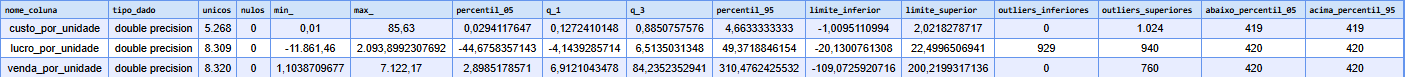

**Verificando se as colunas de Profit e Product Base Margin derivam das outras colunas existentes na base**

```sql
SELECT
    "Sales",
    "Discount",
    "Shipping_Cost",
    "Product_Base_Margin",
    "Profit",

    "Sales" * (1 - "Discount") AS venda_liquida,

    "Sales" *(1- "Product_Base_Margin") AS possivel_custo_produto,

    "Sales" * (1 - "Discount")
        - "Shipping_Cost"
        - "Profit" AS custo_implicito,
        
    "Sales" * (1 - "Discount")
        - "Shipping_Cost" - "Sales" * (1 - "Discount") *(1- "Product_Base_Margin")
        AS profit_teste

FROM db_global_sales.market_fact
LIMIT 10;



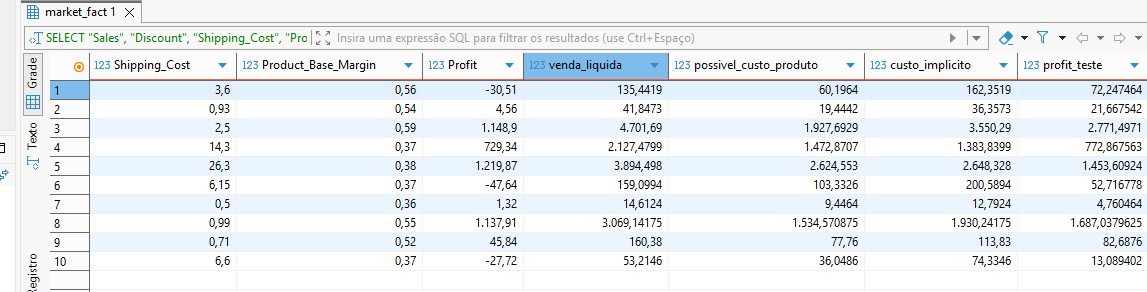)

# **Mapeando das colunas de orders_dimen**

```sql

WITH

order_date AS (

    SELECT
        'Order_Date' AS nome_coluna,
        pg_typeof(o."Order_Date") AS tipo_dado,
        COUNT(DISTINCT o."Order_Date") AS unicos,
        COUNT(*) - COUNT(o."Order_Date") AS nulos
    FROM db_global_sales.orders_dimen AS o
    GROUP BY pg_typeof(o."Order_Date")

),


order_priority AS (

    SELECT
        'Order_Priority' AS nome_coluna,
        pg_typeof(o."Order_Priority") AS tipo_dado,
        COUNT(DISTINCT o."Order_Priority") AS unicos,
        COUNT(*) - COUNT(o."Order_Priority") AS nulos
    FROM db_global_sales.orders_dimen AS o
    GROUP BY pg_typeof(o."Order_Priority")

),


ord_id AS (

    SELECT
        'Ord_id' AS nome_coluna,
        pg_typeof(o."Ord_id") AS tipo_dado,
        COUNT(DISTINCT o."Ord_id") AS unicos,
        COUNT(*) - COUNT(o."Ord_id") AS nulos
    FROM db_global_sales.orders_dimen AS o
    GROUP BY pg_typeof(o."Ord_id")

)


SELECT * FROM order_date

UNION ALL

SELECT * FROM order_priority

UNION ALL

SELECT * FROM ord_id;

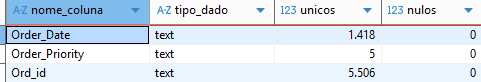

# **Mapeando das colunas de prod_dimen**

```sql
WITH


prod_id AS (

    SELECT
        'Prod_id' AS nome_coluna,
        pg_typeof(p."Prod_id") AS tipo_dado,
        COUNT(DISTINCT p."Prod_id") AS unicos,
        COUNT(*) - COUNT(p."Prod_id") AS nulos
    FROM db_global_sales.prod_dimen AS p
    GROUP BY pg_typeof(p."Prod_id")

),


product_category AS (

    SELECT
        'Product_Category' AS nome_coluna,
        pg_typeof(p."Product_Category") AS tipo_dado,
        COUNT(DISTINCT p."Product_Category") AS unicos,
        COUNT(*) - COUNT(p."Product_Category") AS nulos
    FROM db_global_sales.prod_dimen AS p
    GROUP BY pg_typeof(p."Product_Category")

),


product_sub_category AS (

    SELECT
        'Product_Sub_Category' AS nome_coluna,
        pg_typeof(p."Product_Sub_Category") AS tipo_dado,
        COUNT(DISTINCT p."Product_Sub_Category") AS unicos,
        COUNT(*) - COUNT(p."Product_Sub_Category") AS nulos
    FROM db_global_sales.prod_dimen AS p
    GROUP BY pg_typeof(p."Product_Sub_Category")

)


SELECT * FROM prod_id

UNION ALL

SELECT * FROM product_category

UNION ALL

SELECT * FROM product_sub_category;

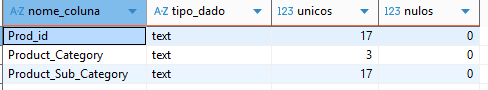

# **Mapeando das colunas de shipping_dimen**

```sql

WITH


order_id AS (

    SELECT
        'Order_ID' AS nome_coluna,
        pg_typeof(s."Order_ID") AS tipo_dado,
        COUNT(DISTINCT s."Order_ID") AS unicos,
        COUNT(*) - COUNT(s."Order_ID") AS nulos
    FROM db_global_sales.shipping_dimen AS s
    GROUP BY pg_typeof(s."Order_ID")

),


ship_mode AS (

    SELECT
        'Ship_Mode' AS nome_coluna,
        pg_typeof(s."Ship_Mode") AS tipo_dado,
        COUNT(DISTINCT s."Ship_Mode") AS unicos,
        COUNT(*) - COUNT(s."Ship_Mode") AS nulos
    FROM db_global_sales.shipping_dimen AS s
    GROUP BY pg_typeof(s."Ship_Mode")

),


ship_date AS (

    SELECT
        'Ship_Date' AS nome_coluna,
        pg_typeof(s."Ship_Date") AS tipo_dado,
        COUNT(DISTINCT s."Ship_Date") AS unicos,
        COUNT(*) - COUNT(s."Ship_Date") AS nulos
    FROM db_global_sales.shipping_dimen AS s
    GROUP BY pg_typeof(s."Ship_Date")

),


ship_id AS (

    SELECT
        'Ship_id' AS nome_coluna,
        pg_typeof(s."Ship_id") AS tipo_dado,
        COUNT(DISTINCT s."Ship_id") AS unicos,
        COUNT(*) - COUNT(s."Ship_id") AS nulos
    FROM db_global_sales.shipping_dimen AS s
    GROUP BY pg_typeof(s."Ship_id")

)


SELECT * FROM order_id

UNION ALL

SELECT * FROM ship_mode

UNION ALL

SELECT * FROM ship_date

UNION ALL

SELECT * FROM ship_id;

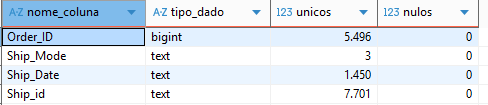

# **Preparando a tabela para a análise em EDA no Python**

```sql
WITH base AS (
    SELECT
        m."Sales" as vendas,
        m."Discount" as descontos,
        m."Order_Quantity" as qtd_unidades,
        m."Profit" as lucro,
        m."Shipping_Cost" as custo_entrega,
        m."Product_Base_Margin" as margem_produto_base,

        m."Sales" / NULLIF(m."Order_Quantity", 0) AS venda_por_unidade,
        m."Profit" / NULLIF(m."Order_Quantity", 0) AS lucro_por_unidade,
        m."Shipping_Cost" / NULLIF(m."Order_Quantity", 0) AS custo_por_unidade,
        m."Sales" - (m."Sales" * m."Discount") as venda_líquida,
        m."Sales" - (m."Sales" * m."Discount") - m."Shipping_Cost" - m."Profit" AS custo_implicito,

        o."Order_Priority" as prioridades_pedidos,
        p."Product_Category" as categorias_produto,
        p."Product_Sub_Category" as sub_categorias_produto,
        s."Ship_Mode" as modo_entrega

    FROM db_global_sales.market_fact AS m

    LEFT JOIN db_global_sales.orders_dimen AS o
        ON m."Ord_id" = o."Ord_id"

    LEFT JOIN db_global_sales.prod_dimen AS p
        ON m."Prod_id" = p."Prod_id"

    LEFT JOIN db_global_sales.shipping_dimen AS s
        ON m."Ship_id" = s."Ship_id"
)

SELECT
    vendas,
    descontos,
    venda_líquida,
    qtd_unidades,
    lucro,
    custo_entrega,
    custo_implicito,
    prioridades_pedidos,
    categorias_produto,
    sub_categorias_produto,
    modo_entrega
FROM base
WHERE venda_por_unidade < 310.476242553191
  AND lucro_por_unidade > -44.6758357143
  AND lucro_por_unidade < 49.371884615384616
  AND custo_por_unidade < 4.663333333333333;

verificando a qtd de linhas removidas c o tratamento de outliers

```sql

WITH base AS (
    SELECT
        m."Sales",
        m."Discount",
        m."Order_Quantity",
        m."Profit",
        m."Shipping_Cost",
        m."Product_Base_Margin",

        m."Sales" / NULLIF(m."Order_Quantity", 0) AS venda_por_unidade,
        m."Profit" / NULLIF(m."Order_Quantity", 0) AS lucro_por_unidade,
        m."Shipping_Cost" / NULLIF(m."Order_Quantity", 0) AS custo_por_unidade,
        m."Sales" - (m."Sales" * m."Discount") - m."Shipping_Cost" - m."Profit" AS custo_implicito,

        o."Order_Priority",
        p."Product_Category",
        p."Product_Sub_Category",
        s."Ship_Mode"

    FROM db_global_sales.market_fact AS m

    LEFT JOIN db_global_sales.orders_dimen AS o
        ON m."Ord_id" = o."Ord_id"

    LEFT JOIN db_global_sales.prod_dimen AS p
        ON m."Prod_id" = p."Prod_id"

    LEFT JOIN db_global_sales.shipping_dimen AS s
        ON m."Ship_id" = s."Ship_id"
)

SELECT
    COUNT(*) AS qtd_linhas_original,
    COUNT(*) FILTER (
        WHERE venda_por_unidade < 310.476242553191
          AND lucro_por_unidade > -44.6758357143
          AND lucro_por_unidade < 49.371884615384616
          AND custo_por_unidade < 4.663333333333333
    ) AS qtd_linhas_tratadas,
    COUNT(*) FILTER (
        WHERE venda_por_unidade >= 310.476242553191
           OR lucro_por_unidade <= -44.6758357143
           OR lucro_por_unidade >= 49.371884615384616
           OR custo_por_unidade >= 4.663333333333333
    ) AS qtd_linhas_removidas
FROM base;

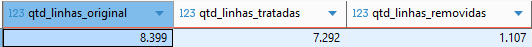

# **Tabelas para exportação pro BI**

**market fact**

```sql
WITH base AS (
    SELECT
        m."Ord_id" as ord_id,
        m."Prod_id" as prod_id,
        m."Ship_id" as ship_id,
        m."Sales" as vendas,
        m."Discount" as descontos,
        m."Order_Quantity" as qtd_unidades,
        m."Profit" as profit,
        m."Shipping_Cost" as shipping_cost,
        m."Product_Base_Margin" as base_margin,

        m."Sales" / NULLIF(m."Order_Quantity", 0) AS venda_por_unidade,
        m."Profit" / NULLIF(m."Order_Quantity", 0) AS lucro_por_unidade,
        m."Shipping_Cost" / NULLIF(m."Order_Quantity", 0) AS custo_por_unidade,
        m."Sales" - (m."Sales" * m."Discount") - m."Shipping_Cost" - m."Profit" AS custo_implicito

    FROM db_global_sales.market_fact AS m
)

SELECT *
FROM base
WHERE venda_por_unidade < 310.476242553191
  AND lucro_por_unidade > -44.6758357143
  AND lucro_por_unidade < 49.371884615384616
  AND custo_por_unidade < 4.663333333333333;

**orders_dimen**

```sql

SELECT
    o."Ord_id" AS ord_id,
    o."Order_Priority" AS prioridade_pedidos,
    TO_DATE(o."Order_Date", 'DD-MM-YYYY') AS data_pedido

FROM db_global_sales.orders_dimen AS o;

**prod_dimen**

```sql
SELECT
	p."Prod_id" as prod_id,
	p."Product_Category" as categoria_produto,
	p."Product_Sub_Category" as subcategoria_produto

FROM db_global_sales.prod_dimen AS p;

**shipping_dimen**

```sql
SELECT
	s."Ship_id" as ship_id,
	s."Ship_Mode" as modo_entrega,
	TO_DATE(s."Ship_Date", 'DD-MM-YYYY') AS data_pedido

FROM db_global_sales.shipping_dimen AS s;